# Beyond Points: A Customer Loyalty Decision Support Tool



Development of a decision‑support tool that uses historical purchase data to segment customers, estimate their churn risk, and recommend personalized loyalty strategies.



1. Data Understanding

3. Business Exploratory Data Analysis
      - Q1. How do customers buy?
      - Q2. How does sales evolve over time?
      - Q3. Are there high-value customers?
      - Q4. Which product categories dominate?
      - Q5. How satisfied are customers?
      - Q6. How long do deliveries take?
      - Q7. Which payment methods are preferred?

5. Data Cleaning

6. Feature Engineering  

7. Customer Analytical Dataset Overview

8. Customer Segmentation

9. Churn Prediction

10. Loyalty Recommendation Engine

11. Conclusions

In [ ]:
import kagglehub

path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print(path)

In [ ]:
!pip install kagglehub pandas

In [ ]:
import pandas as pd

orders_df = pd.read_csv(f"{path}/olist_orders_dataset.csv")

In [ ]:
import os

for file in os.listdir(path):
    print(file)

olist_sellers_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv


In [ ]:
print(path)

/Users/valeriaacevedo/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2


In [ ]:
customers_df = pd.read_csv(f"{path}/olist_customers_dataset.csv")
items_df = pd.read_csv(f"{path}/olist_order_items_dataset.csv")
payments_df = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
products_df = pd.read_csv(f"{path}/olist_products_dataset.csv")
reviews_df = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
translation_df = pd.read_csv(f"{path}/product_category_name_translation.csv")

# 1. Data Understanding

In [ ]:
orders_df.shape
customers_df.shape
items_df.shape
payments_df.shape
products_df.shape
reviews_df.shape

(99224, 7)

In [ ]:
orders_df.shape
orders_df.head()
orders_df.info()

customers_df.info()
items_df.info()
payments_df.info()
products_df.info()
reviews_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        

In [ ]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

Missing Values

In [ ]:
dfs = {
    "Orders": orders_df,
    "Customers": customers_df,
    "Items": items_df,
    "Payments": payments_df,
    "Products": products_df,
    "Reviews": reviews_df
}

for name, df in dfs.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Products
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product

Duplicates

In [ ]:
for name, df in dfs.items():
    print(name, df.duplicated().sum())

Orders 0
Customers 0
Items 0
Payments 0
Products 0
Reviews 0


In [ ]:
orders_df = orders_df.drop_duplicates()

# 2. 

# 2. Business Understanding

🟨 Q1. How do customers buy?  

In [ ]:
order_status = (
    orders_df["order_status"]
    .value_counts()
    .reset_index()
)

order_status.columns = ["Status","Orders"]

order_status

,Status,Orders
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


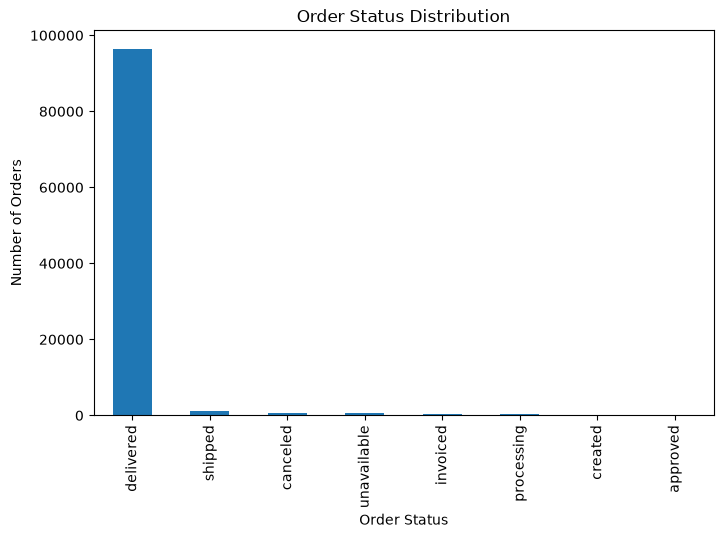

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

orders_df["order_status"].value_counts().plot(
    kind="bar"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

🟨 Q2. How do purchases evolve over time?

In [ ]:
orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"]
)

orders_df["purchase_month"] = (
    orders_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_orders = (
    orders_df
    .groupby("purchase_month")
    .size()
)

monthly_orders

purchase_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
dtype: int64

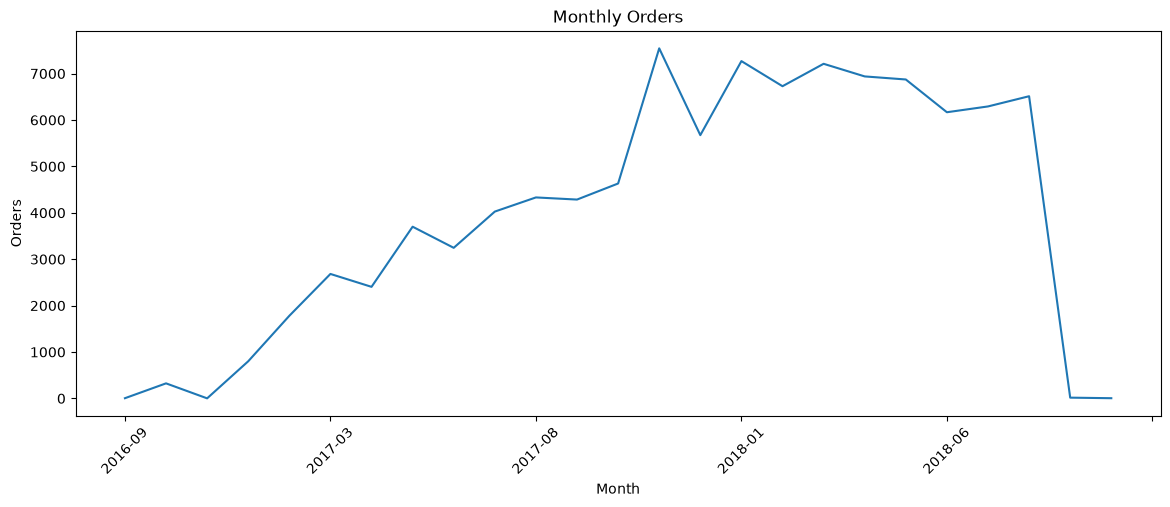

In [ ]:
plt.figure(figsize=(14,5))

monthly_orders.plot()

plt.title("Monthly Orders")

plt.xlabel("Month")

plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.show()

🟨 Q3. Are there high-value customers?

In [ ]:
payments_df["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

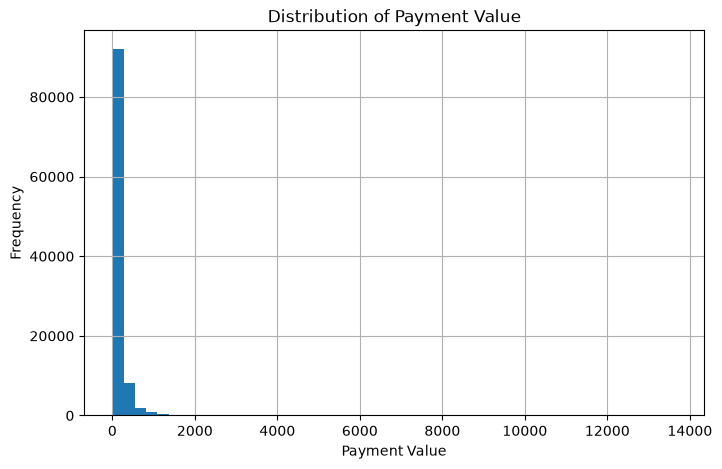

In [ ]:
plt.figure(figsize=(8,5))

payments_df["payment_value"].hist(
    bins=50
)

plt.xlabel("Payment Value")

plt.ylabel("Frequency")

plt.title("Distribution of Payment Value")

plt.show()

# Q4. Which product categories generate most sales?

🟨 Q4. Which product categories generate most sales?

In [ ]:
category_sales = items.merge(
    products,
    on="product_id",
    how="left"
)

top_categories = (
    category_sales["product_category_name"]
    .value_counts()
    .head(10)
)

top_categories

product_category_name
cama_mesa_banho           11115
beleza_saude               9670
esporte_lazer              8641
moveis_decoracao           8334
informatica_acessorios     7827
utilidades_domesticas      6964
relogios_presentes         5991
telefonia                  4545
ferramentas_jardim         4347
automotivo                 4235
Name: count, dtype: int64

In [ ]:
products = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

products.rename(
    columns={
        "product_category_name_english": "product_category"
    },
    inplace=True
)

In [ ]:
print(products.columns.tolist())

['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category']


In [ ]:
category_sales = items.merge(
    products,
    on="product_id",
    how="left"
)

top_categories = (
    category_sales["product_category"]
    .value_counts()
    .head(10)
)

top_categories

product_category
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

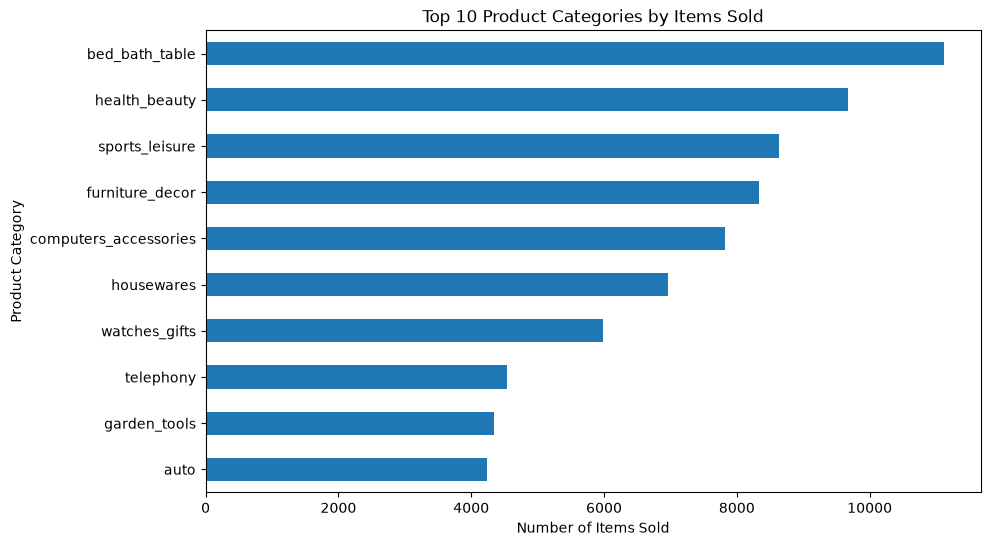

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

top_categories.sort_values().plot(kind="barh")

plt.title("Top 10 Product Categories by Items Sold")
plt.xlabel("Number of Items Sold")
plt.ylabel("Product Category")

plt.show()

🟨 Q5. How satisfied are customers?

In [ ]:
reviews_df["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

<Axes: xlabel='review_score'>

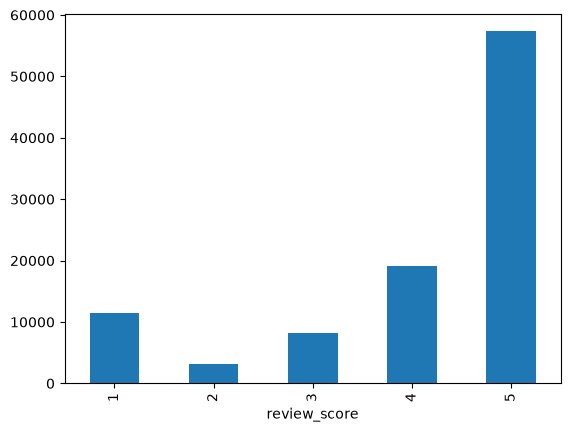

In [ ]:
reviews_df["review_score"].value_counts().sort_index().plot(
    kind="bar"
)

🟨 Q6. How long do deliveries take?

In [ ]:
orders_df["order_purchase_timestamp"] = pd.to_datetime(
    orders_df["order_purchase_timestamp"]
)

orders_df["order_delivered_customer_date"] = pd.to_datetime(
    orders_df["order_delivered_customer_date"]
)

In [ ]:
orders_df["delivery_days"] = (
    orders_df["order_delivered_customer_date"]
    -
    orders_df["order_purchase_timestamp"]
).dt.days

<Axes: xlabel='month'>

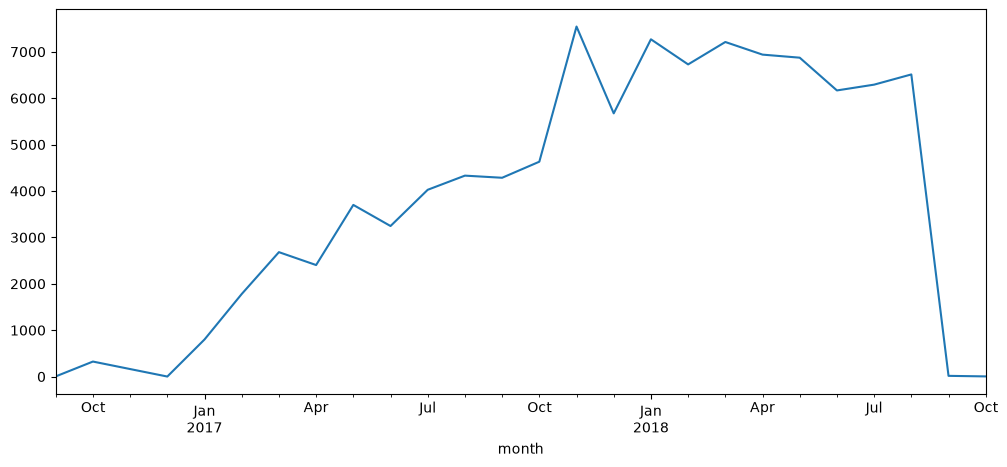

In [ ]:
orders_df["month"] = orders_df["order_purchase_timestamp"].dt.to_period("M")

orders_df.groupby("month").size().plot(figsize=(12,5))

🟨 Q7. Which payment methods do customers prefer?

In [ ]:
payments_df["payment_type"].value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [ ]:
payments_df["payment_value"].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

# 3. Data Cleaning


Dataset

In [100]:
customers = customers_df.copy()
orders = orders_df.copy()
items = items_df.copy()
payments = payments_df.copy()
products = products_df.copy()
reviews = reviews_df.copy()
translation = translation_df.copy()

Convert Date Columns

In [ ]:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

Missing Values

In [ ]:
datasets = {
    "Customers": customers,
    "Orders": orders,
    "Items": items,
    "Payments": payments,
    "Products": products,
    "Reviews": reviews
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


Customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
purchase_month                      0
delivery_days                    2965
month                               0
dtype: int64

Items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Products
product_id                   

Duplicates

In [ ]:

for name, df in datasets.items():
    print(f"{name}: {df.duplicated().sum()} duplicated rows")

Customers: 0 duplicated rows
Orders: 0 duplicated rows
Items: 0 duplicated rows
Payments: 0 duplicated rows
Products: 0 duplicated rows
Reviews: 0 duplicated rows


In [ ]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print(df.shape)

Customers
(99441, 5)
Orders
(99441, 11)
Items
(112650, 7)
Payments
(103886, 5)
Products
(32951, 9)
Reviews
(99224, 5)


Merge Customers + Orders

In [ ]:
customer_orders = customers.merge(
    orders,
    on="customer_id",
    how="left"
)

customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_month,delivery_days,month
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,2017-05-25 10:35:35,2017-06-05,2017-05,8.0,2017-05
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,2018-01-29 12:41:19,2018-02-06,2018-01,16.0,2018-01
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,2018-06-14 17:58:51,2018-06-13,2018-05,26.0,2018-05
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,2018-03-28 16:04:25,2018-04-10,2018-03,14.0,2018-03
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,2018-08-09 20:55:48,2018-08-15,2018-07,11.0,2018-07


In [102]:
customer_df = customers.merge(
    orders,
    on="customer_id",
    how="left"
)

customer_df = customer_df.merge(
    payments,
    on="order_id",
    how="left"
)

customer_df = customer_df.merge(
    items,
    on="order_id",
    how="left"
)

customer_df = customer_df.merge(
    products,
    on="product_id",
    how="left"
)

customer_df = customer_df.merge(
    reviews,
    on="order_id",
    how="left"
)

In [103]:
customer_orders.shape

(119143, 37)

In [104]:
customer_orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    119143 non-null  str           
 1   customer_unique_id             119143 non-null  str           
 2   customer_zip_code_prefix       119143 non-null  int64         
 3   customer_city                  119143 non-null  str           
 4   customer_state                 119143 non-null  str           
 5   order_id                       119143 non-null  str           
 6   order_status                   119143 non-null  str           
 7   order_purchase_timestamp       119143 non-null  datetime64[us]
 8   order_approved_at              118966 non-null  datetime64[us]
 9   order_delivered_carrier_date   117057 non-null  datetime64[us]
 10  order_delivered_customer_date  115722 non-null  datetime64[us]
 11  order_estim

In [ ]:
customer_orders.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,88b8b52d46df026a9d1ad2136a59b30b,4.0,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,5ad6695d76ee186dc473c42706984d87,5.0,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,059a801bb31f6aab2266e672cab87bc5,5.0,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,8490879d58d6c5d7773f2739a03f089a,5.0,2018-08-10 00:00:00,2018-08-17 01:59:52


# 4. Feature Engineering

Analytical Dataset

In [ ]:

customer_df = customers.merge(
    orders,
    on="customer_id",
    how="left"
)

customer_df = customer_df.merge(
    payments,
    on="order_id",
    how="left"
)

customer_df = customer_df.merge(
    items,
    on="order_id",
    how="left"
)

customer_df = customer_df.merge(
    products,
    on="product_id",
    how="left"
)

customer_df = customer_df.merge(
    reviews,
    on="order_id",
    how="left"
)

customer_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_creation_date,review_answer_timestamp
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,1141.0,1.0,8683.0,54.0,64.0,31.0,88b8b52d46df026a9d1ad2136a59b30b,4.0,2017-05-26 00:00:00,2017-05-30 22:34:40
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,1002.0,3.0,10150.0,89.0,15.0,40.0,02fc48a9efa3e3d0f1a8ea26507eeec3,5.0,2018-01-30 00:00:00,2018-02-10 22:43:29
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,955.0,1.0,8267.0,52.0,52.0,17.0,5ad6695d76ee186dc473c42706984d87,5.0,2018-06-15 00:00:00,2018-06-15 12:10:59
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,1066.0,1.0,12160.0,56.0,51.0,28.0,059a801bb31f6aab2266e672cab87bc5,5.0,2018-03-29 00:00:00,2018-04-02 18:36:47
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,407.0,1.0,5200.0,45.0,15.0,35.0,8490879d58d6c5d7773f2739a03f089a,5.0,2018-08-10 00:00:00,2018-08-17 01:59:52


In [ ]:
snapshot_date = customer_df["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

print(snapshot_date)

2018-10-18 17:30:18


RFM Variables

In [ ]:
rfm = customer_df.groupby("customer_unique_id").agg({

    "order_purchase_timestamp": lambda x: (snapshot_date - x.max()).days,

    "order_id": "nunique",

    "payment_value": "sum"

}).reset_index()

rfm.columns = [

    "customer_unique_id",

    "Recency",

    "Frequency",

    "Monetary"

]

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


Average Order Value (AOV)

In [ ]:
rfm["Average_Order_Value"] = (
    rfm["Monetary"] /
    rfm["Frequency"]
)

Customer Tenure

In [ ]:
tenure = customer_df.groupby("customer_unique_id").agg(

    First_Purchase=("order_purchase_timestamp","min"),

    Last_Purchase=("order_purchase_timestamp","max")

).reset_index()

tenure["Customer_Tenure"] = (

    tenure["Last_Purchase"] -

    tenure["First_Purchase"]

).dt.days

In [ ]:
rfm = rfm.merge(

    tenure[

        ["customer_unique_id","Customer_Tenure"]

    ],

    on="customer_unique_id",

    how="left"

)

Average Review Score

In [ ]:
reviews_feature = customer_df.groupby(

    "customer_unique_id"

)["review_score"].mean().reset_index()

reviews_feature.rename(

    columns={

        "review_score":"Average_Review_Score"

    },

    inplace=True

)

Average Review Score

In [ ]:
reviews_feature = customer_df.groupby(

    "customer_unique_id"

)["review_score"].mean().reset_index()

reviews_feature.rename(

    columns={

        "review_score":"Average_Review_Score"

    },

    inplace=True

)

In [ ]:
rfm = rfm.merge(

    reviews_feature,

    on="customer_unique_id",

    how="left"

)

Number of Categories Purchased

In [107]:
customer_df.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_month',
 'delivery_days',
 'month',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [110]:
categories = (
    customer_df
    .groupby("customer_unique_id")["product_category_name"]
    .nunique()
    .reset_index()
)

categories.rename(
    columns={
        "product_category_name": "Unique_Categories"
    },
    inplace=True
)

rfm = rfm.merge(
    categories,
    on="customer_unique_id",
    how="left"
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Average_Order_Value,Customer_Tenure,Average_Review_Score,Total_Items,Average_Basket_Size,Average_Delivery_Days,Cancelled_Orders,Orders_Per_Month,Unique_Categories
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,0,5.0,1,1.0,6.0,0,1.0,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,0,4.0,1,1.0,3.0,0,1.0,1
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,0,3.0,1,1.0,25.0,0,1.0,1
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,0,4.0,1,1.0,20.0,0,1.0,1
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,0,5.0,1,1.0,13.0,0,1.0,1


Total Items Purchased

In [ ]:
items_feature = customer_df.groupby(

    "customer_unique_id"

)["order_item_id"].count().reset_index()

items_feature.rename(

    columns={

        "order_item_id":"Total_Items"

    },

    inplace=True

)

rfm = rfm.merge(

    items_feature,

    on="customer_unique_id",

    how="left"

)

Average Basket Size

In [ ]:
rfm["Average_Basket_Size"] = (

    rfm["Total_Items"] /

    rfm["Frequency"]

)

Average Delivery Time

In [ ]:
customer_df["Delivery_Days"] = (

    customer_df["order_delivered_customer_date"]

    -

    customer_df["order_purchase_timestamp"]

).dt.days

In [ ]:
delivery = customer_df.groupby(

    "customer_unique_id"

)["Delivery_Days"].mean().reset_index()

delivery.rename(

    columns={

        "Delivery_Days":"Average_Delivery_Days"

    },

    inplace=True

)

In [ ]:
rfm = rfm.merge(

    delivery,

    on="customer_unique_id",

    how="left"

)

Cancelled Orders

In [ ]:
cancelled = customer_df.groupby(

    "customer_unique_id"

).agg(

    Cancelled_Orders=(

        "order_status",

        lambda x: (x=="canceled").sum()

    )

).reset_index()

In [ ]:
rfm = rfm.merge(

    cancelled,

    on="customer_unique_id",

    how="left"

)

Orders per Month

In [ ]:
rfm["Orders_Per_Month"] = (

    rfm["Frequency"] /

    (rfm["Customer_Tenure"]/30 + 1)

)

Missing Values

In [ ]:
rfm.isnull().sum()

customer_unique_id          0
Recency                     0
Frequency                   0
Monetary                    0
Average_Order_Value         0
Customer_Tenure             0
Average_Review_Score      716
Total_Items                 0
Average_Basket_Size         0
Average_Delivery_Days    2740
Cancelled_Orders            0
Orders_Per_Month            0
dtype: int64

In [ ]:
rfm["Average_Review_Score"] = rfm["Average_Review_Score"].fillna(0)

rfm["Average_Delivery_Days"] = rfm["Average_Delivery_Days"].fillna(0)

In [ ]:
rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,Average_Order_Value,Customer_Tenure,Average_Review_Score,Total_Items,Average_Basket_Size,Average_Delivery_Days,Cancelled_Orders,Orders_Per_Month
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,141.90,0,5.0,1,1.0,6.0,0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,27.19,0,4.0,1,1.0,3.0,0,1.0
2,0000f46a3911fa3c0805444483337064,586,1,86.22,86.22,0,3.0,1,1.0,25.0,0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,43.62,0,4.0,1,1.0,20.0,0,1.0
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,196.89,0,5.0,1,1.0,13.0,0,1.0


In [ ]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_unique_id     96096 non-null  str    
 1   Recency                96096 non-null  int64  
 2   Frequency              96096 non-null  int64  
 3   Monetary               96096 non-null  float64
 4   Average_Order_Value    96096 non-null  float64
 5   Customer_Tenure        96096 non-null  int64  
 6   Average_Review_Score   96096 non-null  float64
 7   Total_Items            96096 non-null  int64  
 8   Average_Basket_Size    96096 non-null  float64
 9   Average_Delivery_Days  96096 non-null  float64
 10  Cancelled_Orders       96096 non-null  int64  
 11  Orders_Per_Month       96096 non-null  float64
dtypes: float64(6), int64(5), str(1)
memory usage: 8.8 MB


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary,Average_Order_Value,Customer_Tenure,Average_Review_Score,Total_Items,Average_Basket_Size,Average_Delivery_Days,Cancelled_Orders,Orders_Per_Month
count,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000,96096.000000
mean,288.735691,1.034809,214.157343,206.066785,2.711507,4.054262,1.231165,1.183750,11.756991,0.007805,1.003890
std,153.414676,0.214384,644.891987,619.050852,25.393343,1.382389,0.855688,0.718911,9.628972,0.116675,0.135245
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.094044
25%,164.000000,1.000000,64.000000,63.270000,0.000000,4.000000,1.000000,1.000000,6.000000,0.000000,1.000000
50%,269.000000,1.000000,113.340000,111.020000,0.000000,5.000000,1.000000,1.000000,10.000000,0.000000,1.000000
75%,398.000000,1.000000,203.422500,196.360000,0.000000,5.000000,1.000000,1.000000,15.000000,0.000000,1.000000
max,773.000000,17.000000,109312.640000,109312.640000,633.000000,5.000000,75.000000,38.000000,209.000000,9.000000,6.000000


In [83]:
rfm.to_csv("customer_analytical_dataset.csv", index=False)